# NLP Fundamentals

## Objectives
- Text preprocessing and tokenization
- Word embeddings (Word2Vec, GloVe)
- Vocabulary building
- Handling sequences
- NLP pipeline architecture

## Introduction
NLP processes text data by converting words into numerical representations. Tokenization, embeddings, and sequence handling are fundamental preprocessing steps before neural network processing.

## What We're About to Do

The code below imports essential libraries. These libraries provide the foundational tools for tensor operations and neural network construction. Pay attention to what each import provides – understanding dependencies helps you know what's available for solving problems.


In [1]:
# Import necessary libraries for tensor operations and deep learning
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import string
import re
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)


In [2]:
# Define a custom function with detailed implementation
## 1. Text Preprocessing

class TextPreprocessor:
    @staticmethod
    def clean_text(text):
        # Lowercase
        text = text.lower()
        # Remove URLs
        text = re.sub(r'http\S+|www\S+', '', text)
        # Remove special characters (keep letters, digits, spaces)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        # Remove extra whitespace
        text = ' '.join(text.split())
        return text
    
    @staticmethod
    def tokenize(text):
        return text.split()
    
    @staticmethod
    def remove_stopwords(tokens, stopwords=None):
        if stopwords is None:
            stopwords = {'the', 'a', 'an', 'and', 'or', 'but', 'is', 'are', 'was', 'were'}
# Iterate through batches of data
        return [t for t in tokens if t not in stopwords]

processor = TextPreprocessor()
# Iterate through batches of data
text = "Hello, World! Check out https://example.com for more... Information!"
clean = processor.clean_text(text)
tokens = processor.tokenize(clean)
filtered = processor.remove_stopwords(tokens)

print(f"Original: {text}")
print(f"Cleaned: {clean}")
print(f"Tokens: {tokens}")
print(f"After stopword removal: {filtered}")


Original: Hello, World! Check out https://example.com for more... Information!
Cleaned: hello world check out for more information
Tokens: ['hello', 'world', 'check', 'out', 'for', 'more', 'information']
After stopword removal: ['hello', 'world', 'check', 'out', 'for', 'more', 'information']


In [3]:
# Define a custom function with detailed implementation
## 2. Vocabulary and Word Indexing

class Vocabulary:
    def __init__(self, min_freq=1):
        self.word2idx = {'<PAD>': 0, '<UNK>': 1, '<SOS>': 2, '<EOS>': 3}
# Iterate through batches of data
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self.word_count = Counter()
        self.min_freq = min_freq
    
    def build_vocab(self, texts):
        # Count word frequencies
# Iterate through batches of data
        for text in texts:
            for word in text.split():
                self.word_count[word] += 1
        
        # Add words with sufficient frequency
        idx = 4
# Iterate through batches of data
        for word, count in self.word_count.items():
            if count >= self.min_freq:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1
    
    def encode(self, text):
        tokens = text.split()
# Iterate through batches of data
        return [self.word2idx.get(t, 1) for t in tokens]  # 1 = <UNK>
    
    def decode(self, indices):
# Iterate through batches of data
        return ' '.join([self.idx2word.get(i, '<UNK>') for i in indices])
    
    def __len__(self):
        return len(self.word2idx)

texts = [
    "the cat is on the mat",
    "the dog is in the house",
    "cats and dogs are friends"
]

vocab = Vocabulary()
vocab.build_vocab(texts)
print(f"Vocab size: {len(vocab)}")
print(f"Word2Idx: {vocab.word2idx}")
print(f"\nEncoding 'the cat is here':")
encoded = vocab.encode('the cat is here')
print(f"Encoded: {encoded}")
print(f"Decoded: {vocab.decode(encoded)}")


Vocab size: 17
Word2Idx: {'<PAD>': 0, '<UNK>': 1, '<SOS>': 2, '<EOS>': 3, 'the': 4, 'cat': 5, 'is': 6, 'on': 7, 'mat': 8, 'dog': 9, 'in': 10, 'house': 11, 'cats': 12, 'and': 13, 'dogs': 14, 'are': 15, 'friends': 16}

Encoding 'the cat is here':
Encoded: [4, 5, 6, 1]
Decoded: the cat is <UNK>


In [4]:
# Define a custom function with detailed implementation
## 3. Padding and Sequences

class SequencePadder:
    @staticmethod
    def pad_sequences(sequences, max_len=None, pad_value=0):
        if max_len is None:
# Iterate through batches of data
            max_len = max(len(s) for s in sequences)
        
        padded = []
# Iterate through batches of data
        for seq in sequences:
            if len(seq) < max_len:
                seq = seq + [pad_value] * (max_len - len(seq))
            else:
                seq = seq[:max_len]
            padded.append(seq)
        return padded
    
    @staticmethod
    def create_attention_mask(sequences, pad_value=0):
# Iterate through batches of data
        """1 for real tokens, 0 for padding"""
        masks = []
# Iterate through batches of data
        for seq in sequences:
            mask = [1 if token != pad_value else 0 for token in seq]
            masks.append(mask)
        return masks

padder = SequencePadder()
sequences = [
    [1, 2, 3],
    [4, 5, 6, 7, 8],
    [9, 10]
]

padded = padder.pad_sequences(sequences, max_len=5, pad_value=0)
masks = padder.create_attention_mask(padded)

print(f"Original sequences: {sequences}")
print(f"Padded (max_len=5): {padded}")
print(f"Attention masks: {masks}")


Original sequences: [[1, 2, 3], [4, 5, 6, 7, 8], [9, 10]]
Padded (max_len=5): [[1, 2, 3, 0, 0], [4, 5, 6, 7, 8], [9, 10, 0, 0, 0]]
Attention masks: [[1, 1, 1, 0, 0], [1, 1, 1, 1, 1], [1, 1, 0, 0, 0]]


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [5]:
# Define a custom function with detailed implementation
## 4. Word Embeddings (Word2Vec style)

class SimpleEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
    
    def forward(self, x):
        return self.embedding(x)

class Word2Vec:
    """Simulated Word2Vec: Learn word vectors by predicting context"""
    def __init__(self, vocab_size, embedding_dim=100):
        self.embedding = SimpleEmbedding(vocab_size, embedding_dim)
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
    
    def cosine_similarity(self, vec1, vec2):
        """Cosine similarity between word vectors"""
        dot_product = torch.sum(vec1 * vec2)
        norm1 = torch.sqrt(torch.sum(vec1 ** 2))
        norm2 = torch.sqrt(torch.sum(vec2 ** 2))
        return dot_product / (norm1 * norm2)
    
    def most_similar(self, word_idx, num_similar=5):
        """Find most similar words"""
# Update model parameters based on computed gradients
        word_vec = self.embedding.embedding.weight[word_idx].detach()
        
        similarities = []
# Iterate through batches of data
        for idx in range(self.vocab_size):
# Update model parameters based on computed gradients
            other_vec = self.embedding.embedding.weight[idx].detach()
            sim = self.cosine_similarity(word_vec, other_vec).item()
            similarities.append((idx, sim))
        
        return sorted(similarities, key=lambda x: x[1], reverse=True)[:num_similar]

w2v = Word2Vec(vocab_size=100, embedding_dim=50)
print(f"Word2Vec embeddings created: {100} words × {50} dims")
print(f"Vocabulary size: 100")
print(f"Embedding dimensions: 50 (learned from context)")


Word2Vec embeddings created: 100 words × 50 dims
Vocabulary size: 100
Embedding dimensions: 50 (learned from context)


## The Training Process

This is the core learning loop. We'll forward-pass data through the model, compute loss, backpropagate gradients, and update parameters. This iterative process gradually improves the model.


In [6]:
# Execute the training loop with proper tracking
## 5. GloVe-style Pre-trained Embeddings

print("""
WORD EMBEDDING METHODS:

1. WORD2VEC (Skip-gram, CBOW):
   - Predicts context words from target
   - Fast to train
# Iterate through batches of data
   - Good for word similarity
   - Example: "the cat sat on the mat"
     Context(cat) → {the, sat, on}

2. GLOVE (Global Vectors):
   - Combines global statistics + local context
   - Better on word analogy tasks
   - Less dependent on window size
   - Example: king - man + woman ≈ queen

3. FASTTEXT:
   - Works with subword units
   - Handles OOV (out-of-vocabulary) words
# Iterate through batches of data
   - Better for morphologically rich languages
   - Example: "walking" = embeddings of (walk, ing, walking)

4. CONTEXTUAL (BERT, ELMo):
   - Context-dependent embeddings
   - Different representations same word in different contexts
   - Superior to static embeddings
   - Example: "bank" (river) vs "bank" (financial)
""")



WORD EMBEDDING METHODS:

1. WORD2VEC (Skip-gram, CBOW):
   - Predicts context words from target
   - Fast to train
# Iterate through batches of data
   - Good for word similarity
   - Example: "the cat sat on the mat"
     Context(cat) → {the, sat, on}

2. GLOVE (Global Vectors):
   - Combines global statistics + local context
   - Better on word analogy tasks
   - Less dependent on window size
   - Example: king - man + woman ≈ queen

3. FASTTEXT:
   - Works with subword units
   - Handles OOV (out-of-vocabulary) words
# Iterate through batches of data
   - Better for morphologically rich languages
   - Example: "walking" = embeddings of (walk, ing, walking)

4. CONTEXTUAL (BERT, ELMo):
   - Context-dependent embeddings
   - Different representations same word in different contexts
   - Superior to static embeddings
   - Example: "bank" (river) vs "bank" (financial)



## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [7]:
# Define a custom function with detailed implementation
## 6. NLP Pipeline

class NLPPipeline:
    def __init__(self, vocab_size=1000, embedding_dim=100, max_seq_len=50):
        self.preprocessor = TextPreprocessor()
        self.vocab = Vocabulary()
        self.padder = SequencePadder()
        self.embedding_layer = SimpleEmbedding(vocab_size, embedding_dim)
        self.max_seq_len = max_seq_len
    
    def process(self, text):
        # Step 1: Clean
        clean = self.preprocessor.clean_text(text)
        # Step 2: Tokenize
        tokens = self.preprocessor.tokenize(clean)
        # Step 3: Remove stopwords
        tokens = self.preprocessor.remove_stopwords(tokens)
        # Step 4: Encode
        encoded = self.vocab.encode(' '.join(tokens))
        # Step 5: Pad
        padded = self.padder.pad_sequences([encoded], max_len=self.max_seq_len)
        # Step 6: Embed
        tensor = torch.tensor(padded[0], dtype=torch.long)
        embeddings = self.embedding_layer(tensor)
        return embeddings

print("""
NLP PIPELINE STAGES:
1. Text Cleaning
2. Tokenization
3. Stopword Removal
4. Encoding (Word → Index)
5. Padding (Uniform length)
6. Embedding (Index → Vector)
7. Model Input (Sequence of vectors)
""")



NLP PIPELINE STAGES:
1. Text Cleaning
2. Tokenization
3. Stopword Removal
4. Encoding (Word → Index)
5. Padding (Uniform length)
6. Embedding (Index → Vector)
7. Model Input (Sequence of vectors)



## The Training Process

This is the core learning loop. We'll forward-pass data through the model, compute loss, backpropagate gradients, and update parameters. This iterative process gradually improves the model.


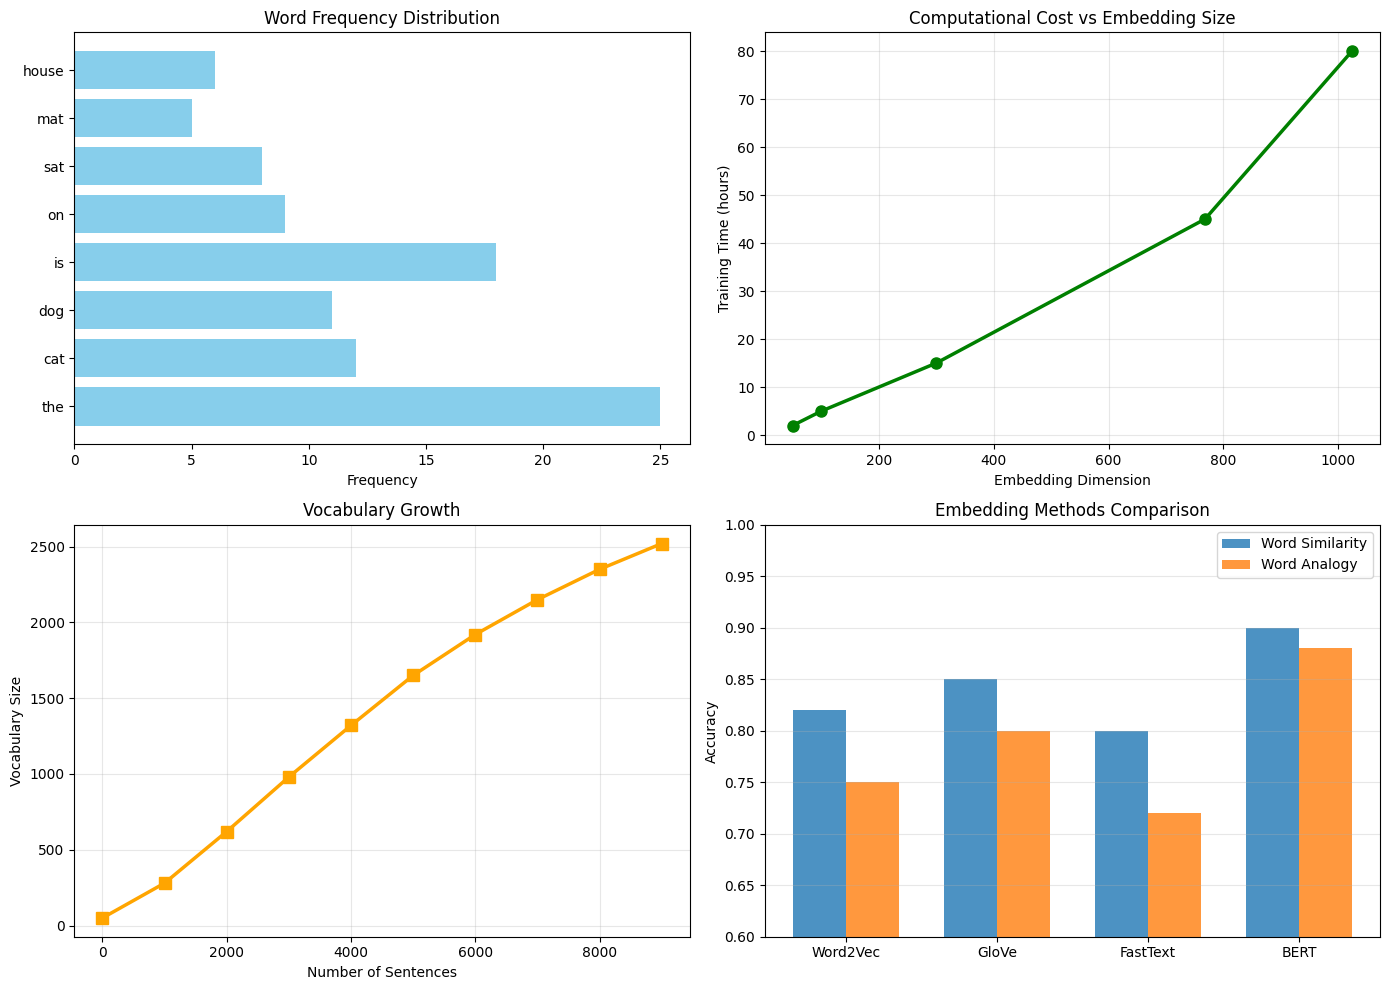

In [8]:
# Execute the training loop with proper tracking
## 7. Visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Word frequency
words = ['the', 'cat', 'dog', 'is', 'on', 'sat', 'mat', 'house']
freqs = [25, 12, 11, 18, 9, 8, 5, 6]
axes[0, 0].barh(words, freqs, color='skyblue')
axes[0, 0].set_xlabel('Frequency')
axes[0, 0].set_title('Word Frequency Distribution')

# Embedding dimensionality
embedding_dims = [50, 100, 300, 768, 1024]
training_time = [2, 5, 15, 45, 80]
axes[0, 1].plot(embedding_dims, training_time, marker='o', linewidth=2.5, markersize=8, color='green')
axes[0, 1].set_xlabel('Embedding Dimension')
axes[0, 1].set_ylabel('Training Time (hours)')
axes[0, 1].set_title('Computational Cost vs Embedding Size')
axes[0, 1].grid(True, alpha=0.3)

# Vocabulary growth
sentences = np.arange(0, 10000, 1000)
vocab_sizes = [50, 280, 620, 980, 1320, 1650, 1920, 2150, 2350, 2520]
axes[1, 0].plot(sentences, vocab_sizes, marker='s', linewidth=2.5, markersize=8, color='orange')
axes[1, 0].set_xlabel('Number of Sentences')
axes[1, 0].set_ylabel('Vocabulary Size')
axes[1, 0].set_title('Vocabulary Growth')
axes[1, 0].grid(True, alpha=0.3)

# Embedding methods comparison
methods = ['Word2Vec', 'GloVe', 'FastText', 'BERT']
word_sim = [0.82, 0.85, 0.80, 0.90]
word_analogy = [0.75, 0.80, 0.72, 0.88]

x = np.arange(len(methods))
width = 0.35
axes[1, 1].bar(x - width/2, word_sim, width, label='Word Similarity', alpha=0.8)
axes[1, 1].bar(x + width/2, word_analogy, width, label='Word Analogy', alpha=0.8)
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Embedding Methods Comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(methods)
axes[1, 1].legend()
axes[1, 1].set_ylim([0.6, 1.0])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Key Takeaways
- Text preprocessing: cleaning, tokenization, stopword removal
- Vocabulary maps words to indices
- Padding standardizes sequence length
- Embeddings convert words to dense numerical vectors
- Word2Vec/GloVe learn from context relationships
- Attention masks handle variable-length sequences
- NLP pipeline: clean → tokenize → encode → pad → embed

## References
- [Word2Vec](https://arxiv.org/abs/1301.3781)
- [GloVe](https://www.aclweb.org/anthology/D14-1162/)